# Machine Learning Lab (23CSE301) – Exercise Solutions
**Chapter 7**


In [1]:
# ---- Common imports and dataset loader ----
import os, re, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

# ---- Dataset loader ----
DATA_DIR = "data"
def load_data(filename, url, **read_csv_kwargs):
    """Read a real dataset. Uses ./data/<filename> if present (e.g. downloaded from Kaggle);
    otherwise downloads the public copy given in `url` and caches it in ./data/."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        os.makedirs(DATA_DIR, exist_ok=True)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp, open(path, "wb") as f:
            f.write(resp.read())
    return pd.read_csv(path, **read_csv_kwargs)

print("Libraries loaded")

Libraries loaded


# 7.6 Decision Tree Classifier – Exercises
## Exercise 1 – Will someone buy a house? (age & income)
Scenario from the book: a tree splits on **age** and **income** to separate buyers from non-buyers, choosing the split that gains the most purity (entropy / Gini).

> **Dataset – California Housing Prices (Kaggle: `camnugent/california-housing-prices`, file `housing.csv`).**
> Link: <https://www.kaggle.com/datasets/camnugent/california-housing-prices>
> **Records:** 20,640 California census block groups · **Features:** `age` (= `housing_median_age`, years), `income` (= `median_income` × $10,000) · **Target:** `bought_house` = 1 if `median_house_value` is above the median of all districts (≈ $179,700), else 0.
> **Preprocessing:** two columns selected and renamed, target created by thresholding a real column; no nulls in these columns. `housing_median_age` is capped at 52 and `median_house_value` at $500,001 in the original data.
> **Caveat:** each row is a *district*, so `age` is the age of the housing stock and `income` the district's median income, not one person's age/income – a stand-in for the exercise's individual-level table.

In [20]:
cal = load_data("housing.csv",
                "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv")
house = pd.DataFrame({
    "age":    cal["housing_median_age"],
    "income": (cal["median_income"] * 10_000).round(-2),
})
house["bought_house"] = (cal["median_house_value"] > cal["median_house_value"].median()).astype(int)

print(house.shape, "| nulls:", house.isnull().sum().sum())
print("\nShare above the median house value:")
print(house.groupby(house.age > 30)["bought_house"].mean().rename({True: "age > 30", False: "age <= 30"}).round(3))
house.head()

(20640, 3) | nulls: 0

Share above the median house value:
age
age <= 30    0.482
age > 30     0.521
Name: bought_house, dtype: float64


,age,income,bought_house
0,41.0,83300.0,1
1,21.0,83000.0,1
2,52.0,72600.0,1
3,52.0,56400.0,1
4,52.0,38500.0,1


In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

X = house[["age", "income"]]; y = house["bought_house"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5, stratify=y)

tree = DecisionTreeClassifier(criterion="entropy", max_depth=2, random_state=5).fit(X_train, y_train)
y_pred = tree.predict(X_test)

print("Confusion matrix:\n", metrics.confusion_matrix(y_test, y_pred))
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred):.3f}\n")
print(export_text(tree, feature_names=["age", "income"]))
print("Feature importance:\n" + pd.Series(tree.feature_importances_, index=X.columns).round(3).to_string())

Confusion matrix:
 [[1798  267]
 [ 775 1288]]
Accuracy: 0.748

|--- income <= 41150.00
|   |--- income <= 26650.00
|   |   |--- class: 0
|   |--- income >  26650.00
|   |   |--- class: 0
|--- income >  41150.00
|   |--- income <= 55850.00
|   |   |--- class: 1
|   |--- income >  55850.00
|   |   |--- class: 1

Feature importance:
age       0.0
income    1.0


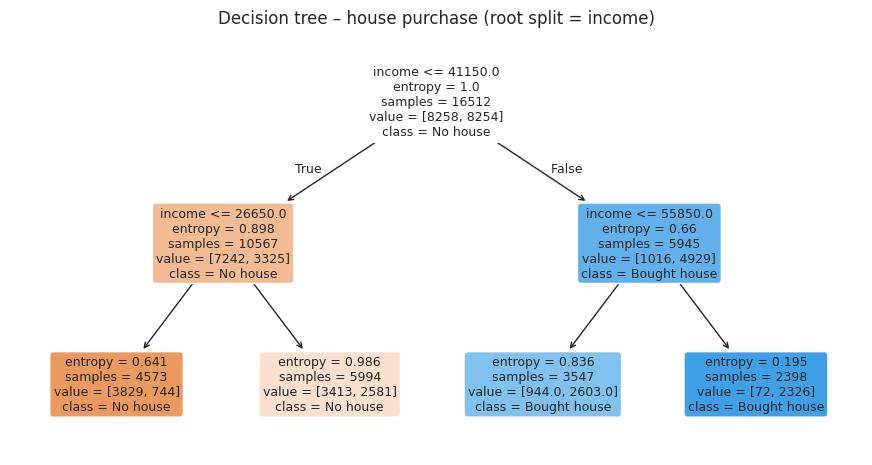

In [22]:
root_feature = ["age", "income"][tree.tree_.feature[0]]
plt.figure(figsize=(11, 5.5))
plot_tree(tree, feature_names=["age", "income"], class_names=["No house", "Bought house"],
          filled=True, rounded=True, fontsize=9)
plt.title(f"Decision tree – house purchase (root split = {root_feature})"); plt.show()

In [23]:
# Purity gained by the first (root) split (Gini impurity), as described in the exercise
def gini(y): p = y.mean(); return 2 * p * (1 - p)
root_feature = X_train.columns[tree.tree_.feature[0]]; threshold = tree.tree_.threshold[0]
left, right = y_train[X_train[root_feature] <= threshold], y_train[X_train[root_feature] > threshold]
w = len(left) / len(y_train)
print(f"Root split                 : {root_feature} <= {threshold:,.1f}")
print(f"Impurity before split      : {gini(y_train):.3f}")
print(f"Impurity after split       : {w*gini(left) + (1-w)*gini(right):.3f}")
print(f"'Bought' share, {root_feature} <= {threshold:,.1f} : {left.mean():.0%}   |   {root_feature} > {threshold:,.1f} : {right.mean():.0%}")
older = y_train[X_train.age > 30]
print(f"Over-30 (age > 30) 'bought' share : {older.mean():.0%}")

Root split                 : income <= 41,150.0
Impurity before split      : 0.500
Impurity after split       : 0.378
'Bought' share, income <= 41,150.0 : 31%   |   income > 41,150.0 : 83%
Over-30 (age > 30) 'bought' share : 52%


## Exercise 2 – Go out or stay in? (weather)
Sunny → picnic / drink / errands (**Go out**); rain → **Stay in**. Categorical weather features are one-hot encoded.

> **Dataset – Play Tennis (Kaggle: `fredericobreno/play-tennis`, file `play_tennis.csv`).**
> Link: <https://www.kaggle.com/datasets/fredericobreno/play-tennis>
> **Records:** 14 days · **Features:** `Outlook`, `Temperature`, `Humidity`, `Wind` · **Target:** `Decision` (`play` = Yes → **Go out**, No → **Stay in**).
> **Preprocessing:** columns renamed and the Yes/No label re-worded to the exercise's Go out / Stay in; one-hot encoding of the four categorical features.
> **Why it fits:** the classic weather-based go-out-or-not table used to teach decision trees; small enough to read the whole tree.

In [24]:
tennis = load_data("play_tennis.csv",
                   "https://raw.githubusercontent.com/jenny-hub90/Decision-Tree-Model-Builiding-from-scratch/master/play_tennis.csv")
weather = tennis.rename(columns={"outlook": "Outlook", "temp": "Temperature", "humidity": "Humidity",
                                 "wind": "Wind", "play": "Decision"})
weather["Decision"] = weather["Decision"].map({"Yes": "Go out", "No": "Stay in"})
print(weather.shape)
weather

(14, 5)


,Outlook,Temperature,Humidity,Wind,Decision
0,Sunny,Hot,High,Weak,Stay in
1,Sunny,Hot,High,Strong,Stay in
2,Overcast,Hot,High,Weak,Go out
3,Rain,Mild,High,Weak,Go out
4,Rain,Cool,Normal,Weak,Go out
5,Rain,Cool,Normal,Strong,Stay in
6,Overcast,Cool,Normal,Strong,Go out
7,Sunny,Mild,High,Weak,Stay in
8,Sunny,Cool,Normal,Weak,Go out
9,Rain,Mild,Normal,Weak,Go out


Training accuracy: 1.00

|--- Outlook_Overcast <= 0.50
|   |--- Humidity_Normal <= 0.50
|   |   |--- Outlook_Rain <= 0.50
|   |   |   |--- class: Stay in
|   |   |--- Outlook_Rain >  0.50
|   |   |   |--- Wind_Strong <= 0.50
|   |   |   |   |--- class: Go out
|   |   |   |--- Wind_Strong >  0.50
|   |   |   |   |--- class: Stay in
|   |--- Humidity_Normal >  0.50
|   |   |--- Wind_Weak <= 0.50
|   |   |   |--- Temperature_Cool <= 0.50
|   |   |   |   |--- class: Go out
|   |   |   |--- Temperature_Cool >  0.50
|   |   |   |   |--- class: Stay in
|   |   |--- Wind_Weak >  0.50
|   |   |   |--- class: Go out
|--- Outlook_Overcast >  0.50
|   |--- class: Go out



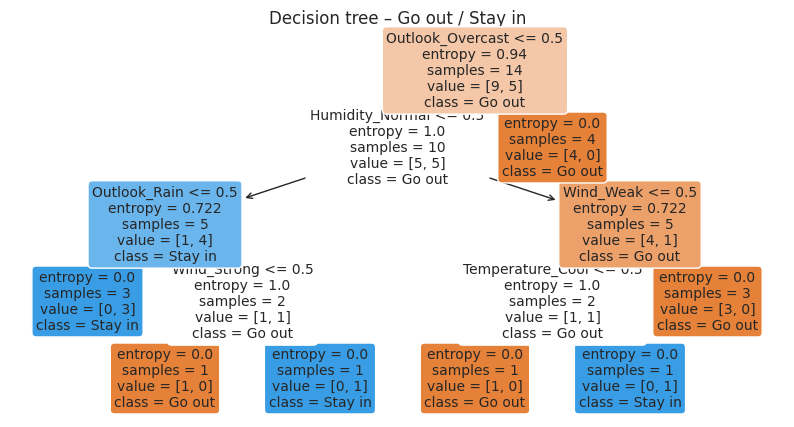

In [25]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

X = pd.get_dummies(weather.drop(columns="Decision")).astype(int)
y = weather["Decision"]

tree = DecisionTreeClassifier(criterion="entropy", random_state=0).fit(X, y)
print(f"Training accuracy: {tree.score(X, y):.2f}\n")
print(export_text(tree, feature_names=list(X.columns)))

plt.figure(figsize=(10, 5))
plot_tree(tree, feature_names=list(X.columns), class_names=list(tree.classes_), filled=True, rounded=True, fontsize=10)
plt.title("Decision tree – Go out / Stay in"); plt.show()

In [26]:
# Predict for new days
new_days = pd.DataFrame([
    {"Outlook": "Sunny",    "Temperature": "Mild", "Humidity": "Normal", "Wind": "Weak"},
    {"Outlook": "Rain",     "Temperature": "Hot",  "Humidity": "High",   "Wind": "Weak"},
    {"Outlook": "Overcast", "Temperature": "Cool", "Humidity": "High",   "Wind": "Strong"},
])
Xn = pd.get_dummies(new_days).reindex(columns=X.columns, fill_value=0).astype(int)
new_days["Prediction"] = tree.predict(Xn)
new_days

,Outlook,Temperature,Humidity,Wind,Prediction
0,Sunny,Mild,Normal,Weak,Go out
1,Rain,Hot,High,Weak,Go out
2,Overcast,Cool,High,Strong,Go out
